In [ ]:
!pip install --upgrade --force-reinstall \
    "torch==2.5.1" \
    "transformers==4.46.3" \
    "datasets==3.1.0" \
    "pyarrow==18.1.0" \
    "accelerate>=0.26.0" \
    "sentencepiece" \
    "protobuf" \
    "pandas" \
    "tqdm" \
    "matplotlib"

In [1]:
import os
import re
import json
import html
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from transformers import pipeline
from tqdm.auto import tqdm
from datasets import load_dataset
from IPython.display import HTML, display

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/transformers/data/metrics/__init__.py:19: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import pearsonr, spearmanr


In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataset and model
DATASET_NAME = "timonziegenbein/appropriateness-corpus"
MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"

# Columns
TEXT_COL = "post_text"
TEXT_NORM_COL = "text_norm"
LABEL_COL = "Inappropriateness"
ID_COL = "post_id"

# Class labels used by the Hugging Face classifier
APPROPRIATE_LABEL = "LABEL_0"
INAPPROPRIATE_LABEL = "LABEL_1"

# Inference settings
MAX_LENGTH = 512
BATCH_SIZE = 16
DEVICE = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Random baseline settings
SPAN_LENGTH_VALUES = [1, 3, 5, 10, 15, 20, 25]
ABLATION_MODES = ["mask", "delete"]

# Main baseline: one contiguous random span.
# Secondary baseline: randomly select a word budget and merge adjacent selected words.
SPAN_SELECTION_MODES = [
    "single_contiguous",
    "multi_word_budgeted",
]
MULTI_WORD_BUDGETED_MIN_LENGTH = 10
N_RANDOM_SAMPLES_PER_CONFIG = 5

# Optional debugging switch.
# Set to an integer, e.g. 50, if you want a quick test run first.
DEBUG_N_ROWS_PER_SPLIT = None

# Output
BASE_DIR = Path("results")
OUTPUT_DIR = BASE_DIR / "random_baseline_results"
PLOTS_DIR = OUTPUT_DIR / "plots"

BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Pipeline device:", DEVICE)
print("Torch device:", TORCH_DEVICE)
print("Output directory:", OUTPUT_DIR)

Pipeline device: 0
Torch device: cuda
Output directory: random_baseline_results


In [3]:
pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=MAX_LENGTH
)

tokenizer = pipe.tokenizer
model = pipe.model
model.to(TORCH_DEVICE)
model.eval()

MASK_TOKEN = tokenizer.mask_token if tokenizer.mask_token is not None else "[MASK]"

print("Mask token:", MASK_TOKEN)
print("Model labels:", model.config.id2label)

Mask token: [MASK]
Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}


In [4]:
ds = load_dataset(DATASET_NAME)

train_df_raw = ds["train"].to_pandas()
val_df_raw = ds["validation"].to_pandas()
test_df_raw = ds["test"].to_pandas()


def attach_split(df, split_name):
    """Add a split column before creating global IDs."""
    df = df.copy().reset_index(drop=True)
    df["split"] = split_name
    return df


df_all = pd.concat(
    [
        attach_split(train_df_raw, "train"),
        attach_split(val_df_raw, "validation"),
        attach_split(test_df_raw, "test"),
    ],
    ignore_index=True
)

# Stable ID for comparing results across methods.
df_all["global_row_id"] = np.arange(len(df_all))

train_df = df_all[df_all["split"] == "train"].copy().reset_index(drop=True)
val_df = df_all[df_all["split"] == "validation"].copy().reset_index(drop=True)
test_df = df_all[df_all["split"] == "test"].copy().reset_index(drop=True)

if DEBUG_N_ROWS_PER_SPLIT is not None:
    train_df = train_df.head(DEBUG_N_ROWS_PER_SPLIT).copy()
    val_df = val_df.head(DEBUG_N_ROWS_PER_SPLIT).copy()
    test_df = test_df.head(DEBUG_N_ROWS_PER_SPLIT).copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

df_all[["global_row_id", "split", ID_COL, LABEL_COL, TEXT_COL]].head()

Train: (1533, 21)
Validation: (220, 21)
Test: (438, 21)


,global_row_id,split,post_id,Inappropriateness,post_text
0,0,train,1,1,"people cant be forced to wear school uniforms,..."
1,1,train,2,1,"That form of argument degrades this forum, and..."
2,2,train,3,0,I wouldnt turn her in becuase she is my wife. ...
3,3,train,4,1,No I wouldn't turn in my spouse. Just because ...
4,4,train,5,1,TV is terrible. Except for Spongebob maybe. Th...


In [5]:
def normalize_text(text: str) -> str:
    """
    Apply minimal normalization only.
    
    This keeps stylistic signals such as capitalization and punctuation mostly intact,
    while normalizing Unicode and whitespace.
    """
    if text is None:
        return ""
    
    text = unicodedata.normalize("NFKC", str(text))
    text = re.sub(r"\s+", " ", text).strip()
    return text


for df in [train_df, val_df, test_df]:
    df[TEXT_NORM_COL] = df[TEXT_COL].apply(normalize_text)

train_df[[TEXT_COL, TEXT_NORM_COL]].head()

,post_text,text_norm
0,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,..."
1,"That form of argument degrades this forum, and...","That form of argument degrades this forum, and..."
2,I wouldnt turn her in becuase she is my wife. ...,I wouldnt turn her in becuase she is my wife. ...
3,No I wouldn't turn in my spouse. Just because ...,No I wouldn't turn in my spouse. Just because ...
4,TV is terrible. Except for Spongebob maybe. Th...,TV is terrible. Except for Spongebob maybe. Th...


In [6]:
def predict_with_pipeline(texts, batch_size=BATCH_SIZE):
    """
    Predict class probabilities and labels with the Hugging Face pipeline.
    
    Returns one row per input text with:
    - p_inappropriate_original
    - predicted_label
    - predicted_score
    """
    rows = []
    
    for start in tqdm(range(0, len(texts), batch_size), desc="Classifier inference"):
        batch_texts = texts[start:start + batch_size]
        outputs = pipe(batch_texts, batch_size=batch_size)
        
        for output in outputs:
            # With top_k=None, the pipeline usually returns a list of label-score dicts.
            if isinstance(output, dict):
                output = [output]
            
            # Some transformers versions return one additional nesting level.
            if (
                isinstance(output, list)
                and len(output) == 1
                and isinstance(output[0], list)
            ):
                output = output[0]
            
            score_by_label = {
                item["label"]: float(item["score"])
                for item in output
            }
            
            predicted_label = max(score_by_label, key=score_by_label.get)
            predicted_score = score_by_label[predicted_label]
            p_inappropriate = score_by_label.get(INAPPROPRIATE_LABEL, np.nan)
            
            rows.append({
                "p_inappropriate_original": p_inappropriate,
                "predicted_label": predicted_label,
                "predicted_score": predicted_score
            })
    
    return pd.DataFrame(rows)

In [8]:
def get_confusion_type(row):
    """Compute confusion type based on gold label and predicted label."""
    gold = int(row[LABEL_COL])
    pred_inappropriate = row["predicted_label"] == INAPPROPRIATE_LABEL

    if gold == 1 and pred_inappropriate:
        return "TP"
    if gold == 1 and not pred_inappropriate:
        return "FN"
    if gold == 0 and pred_inappropriate:
        return "FP"
    if gold == 0 and not pred_inappropriate:
        return "TN"
    
    return "UNKNOWN"


def add_classifier_outputs(df):
    """Add classifier probabilities, predicted labels, and confusion types."""
    df = df.copy()
    
    pred_df = predict_with_pipeline(
        df[TEXT_NORM_COL].astype(str).tolist(),
        batch_size=BATCH_SIZE
    )
    
    df = pd.concat(
        [df.reset_index(drop=True), pred_df.reset_index(drop=True)],
        axis=1
    )
    
    df["confusion_type"] = df.apply(get_confusion_type, axis=1)
    
    df["is_true_positive"] = df["confusion_type"] == "TP"
    df["is_false_negative"] = df["confusion_type"] == "FN"
    df["is_false_positive"] = df["confusion_type"] == "FP"
    df["is_true_negative"] = df["confusion_type"] == "TN"
    
    return df


train_df = add_classifier_outputs(train_df)
val_df = add_classifier_outputs(val_df)
test_df = add_classifier_outputs(test_df)

print("Train confusion types:")
display(train_df["confusion_type"].value_counts())

print("Validation confusion types:")
display(val_df["confusion_type"].value_counts())

print("Test confusion types:")
display(test_df["confusion_type"].value_counts())

Classifier inference:   0%|          | 0/96 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Classifier inference:   0%|          | 0/14 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

Train confusion types:


confusion_type
TP    785
TN    652
FN     48
FP     48
Name: count, dtype: int64

Validation confusion types:


confusion_type
TP    88
TN    66
FN    36
FP    30
Name: count, dtype: int64

Test confusion types:


confusion_type
TP    186
TN    142
FP     71
FN     39
Name: count, dtype: int64

# Random baseline span localization

This notebook evaluates a random span baseline for span-level localization of document-level inappropriateness predictions.

The baseline does not use attribution scores. Instead, it randomly selects text spans and validates their effect through perturbation. If masking or deleting the selected random span decreases the classifier's predicted probability for `LABEL_1`, the span receives a positive `prob_drop`.

Two random selection modes are evaluated:

- `single_contiguous`: selects one contiguous random word span of length `span_length`.
- `multi_word_budgeted`: randomly selects `span_length` individual words and merges adjacent selected words into spans. This produces a multi-span random baseline with the same word budget. Only applied to higher span lenghts (>= 10).

The evaluated configuration dimensions are:

- `span_length`
- `ablation_mode`
- `span_selection_mode`

In [9]:
def get_tokenized_words(text, max_length=MAX_LENGTH):
    """
    Tokenize text and aggregate model subtokens to word-level units.
    
    The returned words contain:
    - character offsets in the normalized text
    - model token indices
    - token texts
    """
    text = str(text)
    
    encoded = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_special_tokens_mask=True
    )
    
    input_ids = encoded["input_ids"]
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    offset_mapping = encoded["offset_mapping"]
    special_tokens_mask = encoded["special_tokens_mask"]
    
    if tokenizer.is_fast:
        word_ids = encoded.word_ids(batch_index=0)
    else:
        word_ids = None
    
    valid_token_mask = []
    
    for i, (start, end) in enumerate(offset_mapping):
        is_real_text_token = (
            special_tokens_mask[i] == 0
            and end > start
            and start >= 0
            and end <= len(text)
        )
        valid_token_mask.append(is_real_text_token)
    
    grouped_words = {}
    
    for token_idx, (offset, is_valid) in enumerate(zip(offset_mapping, valid_token_mask)):
        if not is_valid:
            continue
        
        char_start, char_end = int(offset[0]), int(offset[1])
        
        if word_ids is not None:
            word_id = word_ids[token_idx]
            if word_id is None:
                continue
        else:
            # Fallback: every valid model token becomes its own word-like unit.
            word_id = token_idx
        
        if word_id not in grouped_words:
            grouped_words[word_id] = {
                "token_indices": [],
                "token_texts": [],
                "char_start": char_start,
                "char_end": char_end
            }
        
        grouped_words[word_id]["token_indices"].append(int(token_idx))
        grouped_words[word_id]["token_texts"].append(tokens[token_idx])
        grouped_words[word_id]["char_start"] = min(
            grouped_words[word_id]["char_start"],
            char_start
        )
        grouped_words[word_id]["char_end"] = max(
            grouped_words[word_id]["char_end"],
            char_end
        )
    
    words = []
    
    for word_id in sorted(grouped_words.keys()):
        item = grouped_words[word_id]
        char_start = int(item["char_start"])
        char_end = int(item["char_end"])
        
        words.append({
            "word_index": int(len(words)),
            "char_start": char_start,
            "char_end": char_end,
            "text": text[char_start:char_end],
            "token_indices": item["token_indices"],
            "token_start_idx": int(min(item["token_indices"])),
            "token_end_idx": int(max(item["token_indices"])),
            "token_texts": item["token_texts"],
            "n_tokens": int(len(item["token_indices"]))
        })
    
    try:
        n_tokens_without_truncation = len(
            tokenizer(
                text,
                truncation=False,
                add_special_tokens=True
            )["input_ids"]
        )
        was_truncated = n_tokens_without_truncation > max_length
    except Exception:
        was_truncated = len(input_ids) >= max_length
    
    return {
        "text": text,
        "tokens": tokens,
        "offset_mapping": offset_mapping,
        "valid_token_mask": np.array(valid_token_mask, dtype=bool),
        "words": words,
        "n_model_tokens": int(np.sum(valid_token_mask)),
        "n_words": int(len(words)),
        "was_truncated": bool(was_truncated)
    }

In [10]:
def trim_char_span(text, start, end):
    """Trim whitespace from a character span."""
    while start < end and text[start].isspace():
        start += 1
    while end > start and text[end - 1].isspace():
        end -= 1
    return start, end


def sample_random_word_indices(n_words, span_length, selection_mode, rng):
    """
    Sample random word indices according to the selected random baseline variant.
    
    single_contiguous:
        Select one consecutive word span of length span_length.
    
    multi_word_budgeted:
        Select span_length individual random words and merge adjacent words later.
    """
    if n_words <= 0:
        return []
    
    actual_length = min(int(span_length), int(n_words))
    
    if selection_mode == "single_contiguous":
        start_idx = rng.randint(0, n_words - actual_length)
        return list(range(start_idx, start_idx + actual_length))
    
    if selection_mode == "multi_word_budgeted":
        return sorted(rng.sample(range(n_words), k=actual_length))
    
    raise ValueError(f"Unknown selection_mode: {selection_mode}")


def selected_word_indices_to_spans(token_data, selected_word_indices):
    """
    Convert selected word indices into merged character spans.
    
    Adjacent selected words are merged into one span.
    Non-adjacent selected words become separate spans.
    """
    text = token_data["text"]
    words = token_data["words"]
    
    if not selected_word_indices:
        return []
    
    selected_word_indices = sorted(set(
        idx for idx in selected_word_indices
        if 0 <= idx < len(words)
    ))
    
    if not selected_word_indices:
        return []
    
    groups = []
    current_group = [selected_word_indices[0]]
    
    for idx in selected_word_indices[1:]:
        previous = current_group[-1]
        
        if idx == previous + 1:
            current_group.append(idx)
        else:
            groups.append(current_group)
            current_group = [idx]
    
    groups.append(current_group)
    
    spans = []
    
    for group in groups:
        word_start_idx = min(group)
        word_end_idx = max(group)
        span_words = words[word_start_idx:word_end_idx + 1]
        
        char_start = min(word["char_start"] for word in span_words)
        char_end = max(word["char_end"] for word in span_words)
        char_start, char_end = trim_char_span(text, char_start, char_end)
        
        if char_end <= char_start:
            continue
        
        token_indices_in_span = sorted({
            token_idx
            for word in span_words
            for token_idx in word["token_indices"]
        })
        
        selected_token_indices = sorted({
            token_idx
            for word_idx in group
            for token_idx in words[word_idx]["token_indices"]
        })
        
        spans.append({
            "char_start": int(char_start),
            "char_end": int(char_end),
            "word_start_idx": int(word_start_idx),
            "word_end_idx": int(word_end_idx),
            "token_start_idx": int(min(token_indices_in_span)),
            "token_end_idx": int(max(token_indices_in_span)),
            "span_text": text[char_start:char_end],
            "span_len_chars": int(char_end - char_start),
            "span_len_words": int(word_end_idx - word_start_idx + 1),
            "span_len_tokens": int(len(token_indices_in_span)),
            "selected_word_indices": [int(idx) for idx in group],
            "selected_word_texts": [words[idx]["text"] for idx in group],
            "selected_token_indices": selected_token_indices,
            "selected_token_texts": [
                token_data["tokens"][idx]
                for idx in selected_token_indices
            ],
            "span_score_random": 1.0
        })
    
    for span_idx, span in enumerate(spans):
        span["span_idx"] = int(span_idx)
    
    return spans


def apply_ablation_to_text(text, spans, ablation_mode, mask_token=MASK_TOKEN):
    """
    Apply mask or delete perturbation to the selected spans.
    
    The stored character offsets always refer to the original normalized text.
    """
    text = str(text)
    
    if not spans:
        return text
    
    spans = sorted(spans, key=lambda x: x["char_start"])
    
    parts = []
    last_end = 0
    
    for span in spans:
        start = int(span["char_start"])
        end = int(span["char_end"])
        
        if start < last_end:
            continue
        
        parts.append(text[last_end:start])
        
        if ablation_mode == "mask":
            parts.append(mask_token)
        elif ablation_mode == "delete":
            parts.append("")
        else:
            raise ValueError(f"Unknown ablation_mode: {ablation_mode}")
        
        last_end = end
    
    parts.append(text[last_end:])
    
    perturbed_text = "".join(parts)
    perturbed_text = re.sub(r"\s+", " ", perturbed_text).strip()
    
    return perturbed_text

In [14]:
def stable_rng_for_sample(global_row_id, span_length, sample_id, selection_mode):
    """
    Create a deterministic RNG for one argument/config/sample combination.
    
    This makes the random baseline reproducible and independent of loop order.
    """
    mode_offset = {
        "single_contiguous": 11,
        "multi_word_budgeted": 29
    }[selection_mode]
    
    seed = (
        SEED
        + int(global_row_id) * 1_000_003
        + int(span_length) * 10_007
        + int(sample_id) * 1_009
        + mode_offset
    )
    
    return random.Random(seed)


def run_random_baseline_on_indices(
    df,
    matrix_positions,
    span_length_values=SPAN_LENGTH_VALUES,
    ablation_modes=ABLATION_MODES,
    selection_modes=SPAN_SELECTION_MODES,
    n_random_samples=N_RANDOM_SAMPLES_PER_CONFIG,
    mask_token=MASK_TOKEN
):
    """
    Run random span extraction and perturbation scoring.
    
    matrix_positions are split-local positions into df.
    global_row_id is stored as the stable identifier for downstream comparison.
    """
    all_results = []
    perturbed_texts_to_score = []
    perturbed_lookup = []
    
    for matrix_pos in tqdm(matrix_positions, desc="Building random spans"):
        row = df.iloc[matrix_pos]
        
        text = str(row[TEXT_NORM_COL])
        label = int(row[LABEL_COL])
        global_row_id = int(row["global_row_id"])
        
        try:
            token_data = get_tokenized_words(
                text=text,
                max_length=MAX_LENGTH
            )
            
            n_model_tokens = int(token_data["n_model_tokens"])
            n_words = int(token_data["n_words"])
            
            for selection_mode in selection_modes:
                for span_length in span_length_values:
                    # Skip multi-word random selection for small word budgets.
                    # For small span lengths, this mode mostly creates isolated word masks
                    # rather than meaningful multi-span perturbations.
                    if (
                        selection_mode == "multi_word_budgeted"
                        and span_length < MULTI_WORD_BUDGETED_MIN_LENGTH
                    ):
                        continue
                    for sample_id in range(n_random_samples):
                        rng = stable_rng_for_sample(
                            global_row_id=global_row_id,
                            span_length=span_length,
                            sample_id=sample_id,
                            selection_mode=selection_mode
                        )
                        
                        selected_word_idxs = sample_random_word_indices(
                            n_words=n_words,
                            span_length=span_length,
                            selection_mode=selection_mode,
                            rng=rng
                        )
                        
                        merged_spans = selected_word_indices_to_spans(
                            token_data=token_data,
                            selected_word_indices=selected_word_idxs
                        )
                        
                        selected_token_idxs = sorted({
                            token_idx
                            for span in merged_spans
                            for token_idx in span["selected_token_indices"]
                        })
                        
                        total_masked_tokens = sum(
                            span["span_len_tokens"]
                            for span in merged_spans
                        )
                        total_masked_chars = sum(
                            span["span_len_chars"]
                            for span in merged_spans
                        )
                        
                        masked_token_ratio = (
                            total_masked_tokens / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        selected_token_ratio = (
                            len(selected_token_idxs) / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        selected_word_ratio = (
                            len(selected_word_idxs) / n_words
                            if n_words > 0
                            else 0.0
                        )
                        
                        for ablation_mode in ablation_modes:
                            perturbed_text = apply_ablation_to_text(
                                text=text,
                                spans=merged_spans,
                                ablation_mode=ablation_mode,
                                mask_token=mask_token
                            )
                            
                            result = {
                                "global_row_id": global_row_id,
                                "split": row["split"],
                                "post_id": row[ID_COL] if ID_COL in df.columns else None,
                                "issue": row["issue"] if "issue" in df.columns else None,
                                
                                "label": label,
                                "predicted_label": row["predicted_label"],
                                "predicted_score": float(row["predicted_score"]),
                                "confusion_type": row["confusion_type"],
                                "is_true_positive": bool(row["is_true_positive"]),
                                "is_false_negative": bool(row["is_false_negative"]),
                                "is_false_positive": bool(row["is_false_positive"]),
                                "is_true_negative": bool(row["is_true_negative"]),
                                
                                "attribution_method": "random_baseline",
                                "span_selection_mode": selection_mode,
                                "span_length": int(span_length),
                                "sample_id": int(sample_id),
                                "quantile": np.nan,
                                "window_size": np.nan,
                                "ablation_mode": ablation_mode,
                                
                                "text": text,
                                "perturbed_text": perturbed_text,
                                "masked_text": perturbed_text,
                                
                                "p_inappropriate_original": float(row["p_inappropriate_original"]),
                                
                                "n_model_tokens": n_model_tokens,
                                "n_words": n_words,
                                "n_selected_tokens": int(len(selected_token_idxs)),
                                "n_selected_words": int(len(selected_word_idxs)),
                                "selected_token_ratio": float(selected_token_ratio),
                                "selected_word_ratio": float(selected_word_ratio),
                                
                                "n_merged_spans": int(len(merged_spans)),
                                "total_masked_tokens": int(total_masked_tokens),
                                "total_masked_chars": int(total_masked_chars),
                                "masked_token_ratio": float(masked_token_ratio),
                                
                                "selected_word_indices": [int(idx) for idx in selected_word_idxs],
                                "selected_word_texts": [
                                    token_data["words"][idx]["text"]
                                    for idx in selected_word_idxs
                                    if idx < len(token_data["words"])
                                ],
                                "selected_token_indices": [int(idx) for idx in selected_token_idxs],
                                "selected_token_texts": [
                                    token_data["tokens"][idx]
                                    for idx in selected_token_idxs
                                ],
                                
                                "merged_spans": merged_spans,
                                "was_truncated": bool(token_data["was_truncated"]),
                                "error": None
                            }
                            
                            all_results.append(result)
                            perturbed_lookup.append(len(all_results) - 1)
                            perturbed_texts_to_score.append(perturbed_text)
        
        except Exception as e:
            result = {
                "global_row_id": global_row_id,
                "split": row["split"],
                "post_id": row[ID_COL] if ID_COL in df.columns else None,
                "issue": row["issue"] if "issue" in df.columns else None,
                
                "label": label,
                "predicted_label": row["predicted_label"],
                "predicted_score": float(row["predicted_score"]),
                "confusion_type": row["confusion_type"],
                "is_true_positive": bool(row["is_true_positive"]),
                "is_false_negative": bool(row["is_false_negative"]),
                "is_false_positive": bool(row["is_false_positive"]),
                "is_true_negative": bool(row["is_true_negative"]),
                
                "attribution_method": "random_baseline",
                "span_selection_mode": None,
                "span_length": np.nan,
                "sample_id": np.nan,
                "quantile": np.nan,
                "window_size": np.nan,
                "ablation_mode": None,
                
                "text": text,
                "perturbed_text": text,
                "masked_text": text,
                
                "p_inappropriate_original": float(row["p_inappropriate_original"]),
                "p_inappropriate_perturbed": np.nan,
                "p_inappropriate_masked": np.nan,
                "predicted_label_perturbed": None,
                "predicted_label_masked": None,
                "prob_drop": np.nan,
                
                "n_model_tokens": 0,
                "n_words": 0,
                "n_selected_tokens": 0,
                "n_selected_words": 0,
                "selected_token_ratio": 0.0,
                "selected_word_ratio": 0.0,
                "n_merged_spans": 0,
                "total_masked_tokens": 0,
                "total_masked_chars": 0,
                "masked_token_ratio": 0.0,
                
                "selected_word_indices": [],
                "selected_word_texts": [],
                "selected_token_indices": [],
                "selected_token_texts": [],
                "merged_spans": [],
                "was_truncated": False,
                "error": str(e)
            }
            all_results.append(result)
    
    if len(perturbed_texts_to_score) > 0:
        perturbed_predictions = predict_with_pipeline(
            perturbed_texts_to_score,
            batch_size=BATCH_SIZE
        )
        
        for result_idx, (_, pred_row) in zip(
            perturbed_lookup,
            perturbed_predictions.iterrows()
        ):
            result = all_results[result_idx]
            p_perturbed = float(pred_row["p_inappropriate_original"])
            
            result["p_inappropriate_perturbed"] = p_perturbed
            
            # Compatibility alias for notebooks that expect the IG-style column name.
            result["p_inappropriate_masked"] = p_perturbed
            
            result["predicted_label_perturbed"] = pred_row["predicted_label"]
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(
                result["p_inappropriate_original"] - p_perturbed
            )
    
    return all_results

In [15]:
def build_random_argument_level_df(argument_results):
    """Flatten argument-level random baseline results for CSV export."""
    rows = []
    
    for result in argument_results:
        merged_span_texts = [span["span_text"] for span in result["merged_spans"]]
        merged_span_token_starts = [span["token_start_idx"] for span in result["merged_spans"]]
        merged_span_token_ends = [span["token_end_idx"] for span in result["merged_spans"]]
        merged_span_char_starts = [span["char_start"] for span in result["merged_spans"]]
        merged_span_char_ends = [span["char_end"] for span in result["merged_spans"]]
        
        rows.append({
            "global_row_id": result["global_row_id"],
            "split": result["split"],
            "post_id": result["post_id"],
            "issue": result["issue"],
            
            "label": result["label"],
            "predicted_label": result["predicted_label"],
            "predicted_score": result["predicted_score"],
            "confusion_type": result["confusion_type"],
            "is_true_positive": result["is_true_positive"],
            "is_false_negative": result["is_false_negative"],
            "is_false_positive": result["is_false_positive"],
            "is_true_negative": result["is_true_negative"],
            
            "attribution_method": result["attribution_method"],
            "span_selection_mode": result["span_selection_mode"],
            "span_length": result["span_length"],
            "sample_id": result["sample_id"],
            "quantile": result["quantile"],
            "window_size": result["window_size"],
            "ablation_mode": result["ablation_mode"],
            
            "p_inappropriate_original": result["p_inappropriate_original"],
            "p_inappropriate_perturbed": result.get("p_inappropriate_perturbed", np.nan),
            "p_inappropriate_masked": result.get("p_inappropriate_masked", np.nan),
            "predicted_label_perturbed": result.get("predicted_label_perturbed", None),
            "predicted_label_masked": result.get("predicted_label_masked", None),
            "prob_drop": result.get("prob_drop", np.nan),
            
            "n_model_tokens": result["n_model_tokens"],
            "n_words": result["n_words"],
            "n_selected_tokens": result["n_selected_tokens"],
            "n_selected_words": result["n_selected_words"],
            "selected_token_ratio": result["selected_token_ratio"],
            "selected_word_ratio": result["selected_word_ratio"],
            
            "n_merged_spans": result["n_merged_spans"],
            "total_masked_tokens": result["total_masked_tokens"],
            "total_masked_chars": result["total_masked_chars"],
            "masked_token_ratio": result["masked_token_ratio"],
            
            "selected_word_indices": result["selected_word_indices"],
            "selected_word_texts": result["selected_word_texts"],
            "selected_token_indices": result["selected_token_indices"],
            "selected_token_texts": result["selected_token_texts"],
            
            "merged_span_texts": merged_span_texts,
            "merged_span_token_start_indices": merged_span_token_starts,
            "merged_span_token_end_indices": merged_span_token_ends,
            "merged_span_char_start_indices": merged_span_char_starts,
            "merged_span_char_end_indices": merged_span_char_ends,
            
            "selected_words_json": json.dumps(result["selected_word_texts"], ensure_ascii=False),
            "selected_tokens_json": json.dumps(result["selected_token_texts"], ensure_ascii=False),
            "merged_spans_json": json.dumps(result["merged_spans"], ensure_ascii=False),
            
            "was_truncated": result["was_truncated"],
            "text": result["text"],
            "perturbed_text": result["perturbed_text"],
            "masked_text": result["masked_text"],
            "error": result["error"]
        })
    
    return pd.DataFrame(rows)


def build_random_span_level_df(argument_results):
    """Flatten span-level random baseline results for CSV export."""
    span_rows = []
    
    for result in argument_results:
        for span in result["merged_spans"]:
            span_rows.append({
                "global_row_id": result["global_row_id"],
                "split": result["split"],
                "post_id": result["post_id"],
                "issue": result["issue"],
                
                "label": result["label"],
                "predicted_label": result["predicted_label"],
                "confusion_type": result["confusion_type"],
                "is_true_positive": result["is_true_positive"],
                "is_false_negative": result["is_false_negative"],
                "is_false_positive": result["is_false_positive"],
                "is_true_negative": result["is_true_negative"],
                
                "attribution_method": result["attribution_method"],
                "span_selection_mode": result["span_selection_mode"],
                "span_length": result["span_length"],
                "sample_id": result["sample_id"],
                "quantile": result["quantile"],
                "window_size": result["window_size"],
                "ablation_mode": result["ablation_mode"],
                
                "span_idx": span["span_idx"],
                "span_text": span["span_text"],
                "char_start": span["char_start"],
                "char_end": span["char_end"],
                "word_start_idx": span["word_start_idx"],
                "word_end_idx": span["word_end_idx"],
                "token_start_idx": span["token_start_idx"],
                "token_end_idx": span["token_end_idx"],
                "span_len_chars": span["span_len_chars"],
                "span_len_words": span["span_len_words"],
                "span_len_tokens": span["span_len_tokens"],
                
                "selected_word_indices": span["selected_word_indices"],
                "selected_word_texts": span["selected_word_texts"],
                "selected_token_indices": span["selected_token_indices"],
                "selected_token_texts": span["selected_token_texts"],
                "span_score_random": span["span_score_random"],
                
                "p_inappropriate_original": result["p_inappropriate_original"],
                "p_inappropriate_perturbed": result.get("p_inappropriate_perturbed", np.nan),
                "p_inappropriate_masked": result.get("p_inappropriate_masked", np.nan),
                "prob_drop": result.get("prob_drop", np.nan),
                
                "n_model_tokens": result["n_model_tokens"],
                "n_words": result["n_words"],
                "n_selected_tokens": result["n_selected_tokens"],
                "n_selected_words": result["n_selected_words"],
                "selected_token_ratio": result["selected_token_ratio"],
                "selected_word_ratio": result["selected_word_ratio"],
                "masked_token_ratio": result["masked_token_ratio"],
                
                "was_truncated": result["was_truncated"],
                "text": result["text"],
                "perturbed_text": result["perturbed_text"],
                "masked_text": result["masked_text"]
            })
    
    return pd.DataFrame(span_rows)

In [18]:
def run_random_baseline_on_split(df, split_name):
    """
    Run all random baseline configurations on one split.
    
    The random baseline is not trained and not tuned. All predefined configs
    are applied directly to each split.
    """
    positions = list(range(len(df)))
    
    results = run_random_baseline_on_indices(
        df=df,
        matrix_positions=positions,
        span_length_values=SPAN_LENGTH_VALUES,
        ablation_modes=ABLATION_MODES,
        selection_modes=SPAN_SELECTION_MODES,
        n_random_samples=N_RANDOM_SAMPLES_PER_CONFIG,
        mask_token=MASK_TOKEN
    )
    
    argument_df = build_random_argument_level_df(results)
    span_df = build_random_span_level_df(results)
    
    print(f"{split_name} argument level:", argument_df.shape)
    print(f"{split_name} span level:", span_df.shape)
    
    return results, argument_df, span_df


train_results, train_argument_df, train_span_df = run_random_baseline_on_split(
    train_df,
    "train"
)

val_results, val_argument_df, val_span_df = run_random_baseline_on_split(
    val_df,
    "validation"
)

test_results, test_argument_df, test_span_df = run_random_baseline_on_split(
    test_df,
    "test"
)

Building random spans:   0%|          | 0/1533 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/10540 [00:00<?, ?it/s]

train argument level: (168630, 52)
train span level: (819688, 49)


Building random spans:   0%|          | 0/220 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/1513 [00:00<?, ?it/s]

validation argument level: (24200, 52)
validation span level: (119118, 49)


Building random spans:   0%|          | 0/438 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/3012 [00:00<?, ?it/s]

test argument level: (48180, 52)
test span level: (235950, 49)


In [19]:
final_argument_df = pd.concat(
    [train_argument_df, val_argument_df, test_argument_df],
    ignore_index=True
)

final_span_df = pd.concat(
    [train_span_df, val_span_df, test_span_df],
    ignore_index=True
)

display(final_argument_df.head())
display(final_span_df.head())

print("Final argument-level rows:", len(final_argument_df))
print("Final span-level rows:", len(final_span_df))

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_char_start_indices,merged_span_char_end_indices,selected_words_json,selected_tokens_json,merged_spans_json,was_truncated,text,perturbed_text,masked_text,error
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[157],[166],"["" principal""]","[""▁principal""]","[{""char_start"": 157, ""char_end"": 166, ""word_st...",False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...",None
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[157],[166],"["" principal""]","[""▁principal""]","[{""char_start"": 157, ""char_end"": 166, ""word_st...",False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...",None
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[127],[133],"["" school""]","[""▁school""]","[{""char_start"": 127, ""char_end"": 133, ""word_st...",False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...",None
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[127],[133],"["" school""]","[""▁school""]","[{""char_start"": 127, ""char_end"": 133, ""word_st...",False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...",None
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[144],[145],"["" I""]","[""▁I""]","[{""char_start"": 144, ""char_end"": 145, ""word_st...",False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...",None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,n_words,n_selected_tokens,n_selected_words,selected_token_ratio,selected_word_ratio,masked_token_ratio,was_truncated,text,perturbed_text,masked_text
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,1,1,0.02381,0.026316,0.02381,False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,..."
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,1,1,0.02381,0.026316,0.02381,False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,..."
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,1,1,0.02381,0.026316,0.02381,False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,..."
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,1,1,0.02381,0.026316,0.02381,False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,..."
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,1,1,0.02381,0.026316,0.02381,False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,..."


Final argument-level rows: 241010
Final span-level rows: 1174756


In [20]:
def make_json_serializable(obj):
    """Convert numpy and pandas scalar types to JSON-serializable Python types."""
    if isinstance(obj, dict):
        return {str(k): make_json_serializable(v) for k, v in obj.items()}
    
    if isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]
    
    if isinstance(obj, tuple):
        return [make_json_serializable(v) for v in obj]
    
    if isinstance(obj, np.integer):
        return int(obj)
    
    if isinstance(obj, np.floating):
        return float(obj)
    
    if isinstance(obj, np.bool_):
        return bool(obj)
    
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    
    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass
    
    return obj


argument_csv_path = OUTPUT_DIR / "random_final_all_splits_argument_level.csv"
span_csv_path = OUTPUT_DIR / "random_final_all_splits_span_level.csv"
jsonl_path = OUTPUT_DIR / "random_final_all_splits_argument_level.jsonl"

final_argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
final_span_df.to_csv(span_csv_path, index=False, encoding="utf-8")

all_results = train_results + val_results + test_results

with open(jsonl_path, "w", encoding="utf-8") as f:
    for result in all_results:
        safe_result = make_json_serializable(result)
        f.write(json.dumps(safe_result, ensure_ascii=False) + "\n")

print("Saved:")
print(argument_csv_path)
print(span_csv_path)
print(jsonl_path)

Saved:
random_baseline_results/random_final_all_splits_argument_level.csv
random_baseline_results/random_final_all_splits_span_level.csv
random_baseline_results/random_final_all_splits_argument_level.jsonl


In [21]:
final_argument_df_valid = final_argument_df[
    final_argument_df["error"].isna()
].copy()

# First aggregate random samples per argument and config.
# This prevents configs with multiple random samples from being interpreted as independent arguments.
per_argument_config_df = (
    final_argument_df_valid
    .groupby(
        [
            "split",
            "global_row_id",
            "post_id",
            "label",
            "confusion_type",
            "span_selection_mode",
            "span_length",
            "ablation_mode"
        ],
        as_index=False
    )
    .agg(
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        max_prob_drop=("prob_drop", "max"),
        min_prob_drop=("prob_drop", "min"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_perturbed=("p_inappropriate_perturbed", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        mean_selected_word_ratio=("selected_word_ratio", "mean"),
        truncation_rate=("was_truncated", lambda x: x.mean()),
        n_random_samples=("sample_id", "nunique")
    )
)

config_summary = (
    per_argument_config_df
    .groupby(
        [
            "split",
            "span_selection_mode",
            "span_length",
            "ablation_mode"
        ],
        as_index=False
    )
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("mean_prob_drop", "mean"),
        median_prob_drop=("mean_prob_drop", "median"),
        std_prob_drop=("mean_prob_drop", "std"),
        mean_max_prob_drop=("max_prob_drop", "mean"),
        positive_drop_rate=("positive_drop_rate", "mean"),
        strong_drop_rate_001=("strong_drop_rate_001", "mean"),
        strong_drop_rate_005=("strong_drop_rate_005", "mean"),
        mean_p_original=("mean_p_original", "mean"),
        mean_p_perturbed=("mean_p_perturbed", "mean"),
        mean_n_merged_spans=("mean_n_merged_spans", "mean"),
        mean_total_masked_tokens=("mean_total_masked_tokens", "mean"),
        mean_total_masked_chars=("mean_total_masked_chars", "mean"),
        mean_masked_token_ratio=("mean_masked_token_ratio", "mean"),
        mean_selected_word_ratio=("mean_selected_word_ratio", "mean"),
        truncation_rate=("truncation_rate", "mean")
    )
    .sort_values(
        [
            "split",
            "span_selection_mode",
            "ablation_mode",
            "span_length"
        ]
    )
)

display(per_argument_config_df.head())
display(config_summary)

,split,global_row_id,post_id,label,confusion_type,span_selection_mode,span_length,ablation_mode,mean_prob_drop,median_prob_drop,...,strong_drop_rate_005,mean_p_original,mean_p_perturbed,mean_n_merged_spans,mean_total_masked_tokens,mean_total_masked_chars,mean_masked_token_ratio,mean_selected_word_ratio,truncation_rate,n_random_samples
0,test,1753,0,1,FN,multi_word_budgeted,10,delete,-0.507166,-0.392019,...,0.0,0.107274,0.614439,2.2,10.0,55.2,0.833333,0.833333,0.0,5
1,test,1753,0,1,FN,multi_word_budgeted,10,mask,-0.777225,-0.773776,...,0.0,0.107274,0.884499,2.2,10.0,55.2,0.833333,0.833333,0.0,5
2,test,1753,0,1,FN,multi_word_budgeted,15,delete,-0.304704,-0.304704,...,0.0,0.107274,0.411978,1.0,12.0,69.0,1.000000,1.000000,0.0,5
3,test,1753,0,1,FN,multi_word_budgeted,15,mask,-0.326867,-0.326867,...,0.0,0.107274,0.434140,1.0,12.0,69.0,1.000000,1.000000,0.0,5
4,test,1753,0,1,FN,multi_word_budgeted,20,delete,-0.304704,-0.304704,...,0.0,0.107274,0.411978,1.0,12.0,69.0,1.000000,1.000000,0.0,5


,split,span_selection_mode,span_length,ablation_mode,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_max_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_perturbed,mean_n_merged_spans,mean_total_masked_tokens,mean_total_masked_chars,mean_masked_token_ratio,mean_selected_word_ratio,truncation_rate
0,test,multi_word_budgeted,10,delete,438,-0.089353,-0.000185,0.236434,0.018152,0.408219,0.089041,0.051142,0.590804,0.680157,8.205479,12.037443,47.154338,0.198473,0.199175,0.0
2,test,multi_word_budgeted,15,delete,438,-0.104960,-0.000325,0.324740,0.019651,0.395434,0.122374,0.097717,0.590804,0.695764,10.942922,17.920091,71.190868,0.290103,0.290928,0.0
4,test,multi_word_budgeted,20,delete,438,-0.134548,-0.000341,0.385612,-0.001706,0.404566,0.150685,0.124658,0.590804,0.725352,13.085388,23.659361,95.191324,0.365818,0.365105,0.0
6,test,multi_word_budgeted,25,delete,438,-0.152807,-0.000522,0.437529,-0.025563,0.413242,0.176256,0.159361,0.590804,0.743611,14.636073,29.067580,118.533790,0.431235,0.431224,0.0
1,test,multi_word_budgeted,10,mask,438,-0.100077,-0.000189,0.244404,-0.013104,0.460731,0.071233,0.036073,0.590804,0.690881,8.205479,12.037443,47.154338,0.198473,0.199175,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,validation,single_contiguous,5,mask,220,-0.040391,-0.000167,0.144848,0.025379,0.400909,0.083636,0.030909,0.542075,0.582466,1.000000,5.888182,26.830909,0.097237,0.099158,0.0
59,validation,single_contiguous,10,mask,220,-0.053679,-0.000172,0.197256,0.034570,0.380000,0.100000,0.055455,0.542075,0.595754,1.000000,11.818182,54.411818,0.195851,0.198316,0.0
61,validation,single_contiguous,15,mask,220,-0.049684,-0.000271,0.247391,0.067398,0.379091,0.146364,0.095455,0.542075,0.591759,1.000000,17.591818,81.844545,0.284028,0.286955,0.0
63,validation,single_contiguous,20,mask,220,-0.045889,-0.000537,0.278670,0.075499,0.393636,0.164545,0.112727,0.542075,0.587964,1.000000,23.169091,107.946364,0.357433,0.360592,0.0


In [22]:
val_tp_config_summary = config_summary[
    config_summary["split"].eq("validation")
].copy()

# Recompute specifically on validation true positives.
val_tp_per_argument_config_df = per_argument_config_df[
    (per_argument_config_df["split"] == "validation") &
    (per_argument_config_df["confusion_type"] == "TP")
].copy()

val_tp_config_summary = (
    val_tp_per_argument_config_df
    .groupby(
        [
            "span_selection_mode",
            "span_length",
            "ablation_mode"
        ],
        as_index=False
    )
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("mean_prob_drop", "mean"),
        median_prob_drop=("mean_prob_drop", "median"),
        std_prob_drop=("mean_prob_drop", "std"),
        mean_max_prob_drop=("max_prob_drop", "mean"),
        positive_drop_rate=("positive_drop_rate", "mean"),
        strong_drop_rate_001=("strong_drop_rate_001", "mean"),
        strong_drop_rate_005=("strong_drop_rate_005", "mean"),
        mean_p_original=("mean_p_original", "mean"),
        mean_p_perturbed=("mean_p_perturbed", "mean"),
        mean_n_merged_spans=("mean_n_merged_spans", "mean"),
        mean_total_masked_tokens=("mean_total_masked_tokens", "mean"),
        mean_total_masked_chars=("mean_total_masked_chars", "mean"),
        mean_masked_token_ratio=("mean_masked_token_ratio", "mean"),
        mean_selected_word_ratio=("mean_selected_word_ratio", "mean"),
        truncation_rate=("truncation_rate", "mean")
    )
    .sort_values(
        [
            "span_selection_mode",
            "ablation_mode",
            "span_length"
        ]
    )
)

display(val_tp_config_summary)

,span_selection_mode,span_length,ablation_mode,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_max_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_perturbed,mean_n_merged_spans,mean_total_masked_tokens,mean_total_masked_chars,mean_masked_token_ratio,mean_selected_word_ratio,truncation_rate
0,multi_word_budgeted,10,delete,88,0.043026,0.000204,0.153322,0.101205,0.515909,0.122727,0.102273,0.981915,0.938889,7.918182,12.115909,47.011364,0.237306,0.238736,0.0
2,multi_word_budgeted,15,delete,88,0.059997,0.000165,0.183853,0.103702,0.538636,0.152273,0.131818,0.981915,0.921918,10.293182,17.929545,70.275000,0.335136,0.335178,0.0
4,multi_word_budgeted,20,delete,88,0.080427,0.000368,0.193908,0.134293,0.577273,0.204545,0.179545,0.981915,0.901489,12.095455,23.370455,94.050000,0.415512,0.415859,0.0
6,multi_word_budgeted,25,delete,88,0.128407,0.000336,0.242660,0.158885,0.611364,0.259091,0.250000,0.981915,0.853509,13.445455,28.652273,116.340909,0.484950,0.483889,0.0
1,multi_word_budgeted,10,mask,88,0.025530,0.000441,0.121292,0.071377,0.663636,0.095455,0.079545,0.981915,0.956385,7.918182,12.115909,47.011364,0.237306,0.238736,0.0
3,multi_word_budgeted,15,mask,88,0.051769,0.000473,0.173305,0.094041,0.681818,0.145455,0.120455,0.981915,0.930147,10.293182,17.929545,70.275000,0.335136,0.335178,0.0
5,multi_word_budgeted,20,mask,88,0.067544,0.000500,0.189324,0.113204,0.704545,0.197727,0.156818,0.981915,0.914372,12.095455,23.370455,94.050000,0.415512,0.415859,0.0
7,multi_word_budgeted,25,mask,88,0.120283,0.000578,0.231496,0.146242,0.722727,0.279545,0.252273,0.981915,0.861632,13.445455,28.652273,116.340909,0.484950,0.483889,0.0
8,single_contiguous,1,delete,88,0.002348,-0.000005,0.028034,0.025361,0.481818,0.031818,0.015909,0.981915,0.979567,1.000000,1.190909,4.172727,0.022647,0.023874,0.0
10,single_contiguous,3,delete,88,0.010310,0.000004,0.052929,0.050750,0.429545,0.047727,0.040909,0.981915,0.971606,1.000000,3.654545,15.661364,0.070090,0.071621,0.0


In [23]:
# Best random sample per argument and configuration
# This keeps the configuration fixed and only selects the best random draw
# among repeated samples for the same argument/config.

best_per_argument_per_config_df = (
    final_argument_df_valid
    .dropna(subset=["prob_drop"])
    .sort_values("prob_drop", ascending=False)
    .groupby(
        [
            "split",
            "global_row_id",
            "span_selection_mode",
            "span_length",
            "ablation_mode"
        ],
        as_index=False
    )
    .head(1)
    .reset_index(drop=True)
)

best_per_argument_per_config_df["best_selection_type"] = "best_sample_per_argument_per_config"

display(best_per_argument_per_config_df.head())

print("Rows:", len(best_per_argument_per_config_df))
print("Arguments:", best_per_argument_per_config_df["global_row_id"].nunique())

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_char_end_indices,selected_words_json,selected_tokens_json,merged_spans_json,was_truncated,text,perturbed_text,masked_text,error,best_selection_type
0,2111,test,1769,Tv is better than books:,0,LABEL_1,0.998197,FP,False,False,...,[131],"["" tv"", "" keep"", "" on"", "" saying"", "" that"", "" ...","[""▁tv"", ""▁keep"", ""▁on"", ""▁saying"", ""▁that"", ""▁...","[{""char_start"": 23, ""char_end"": 131, ""word_sta...",False,People who are against tv keep on saying that ...,People who are against I think it is much easi...,People who are against I think it is much easi...,None,best_sample_per_argument_per_config
1,2111,test,1769,Tv is better than books:,0,LABEL_1,0.998197,FP,False,False,...,[131],"["" tv"", "" keep"", "" on"", "" saying"", "" that"", "" ...","[""▁tv"", ""▁keep"", ""▁on"", ""▁saying"", ""▁that"", ""▁...","[{""char_start"": 23, ""char_end"": 131, ""word_sta...",False,People who are against tv keep on saying that ...,People who are against [MASK] I think it is mu...,People who are against [MASK] I think it is mu...,None,best_sample_per_argument_per_config
2,1803,test,250,Is there a difference between racial and crimi...,0,LABEL_1,0.998246,FP,False,False,...,[416],"["" an"", "" increase"", "" in"", "" criminal"", "" beh...","[""▁an"", ""▁increase"", ""▁in"", ""▁criminal"", ""▁beh...","[{""char_start"": 224, ""char_end"": 416, ""word_st...",False,if your society systematically puts down or pu...,if your society systematically puts down or pu...,if your society systematically puts down or pu...,None,best_sample_per_argument_per_config
3,1719,validation,1858,Are humans above the title of animal? stance...,1,LABEL_1,0.997230,TP,True,False,...,[172],"["" animals."", "" And"", "" how"", "" can"", "" a"", "" ...","[""▁animals"", ""."", ""▁And"", ""▁how"", ""▁can"", ""▁a""...","[{""char_start"": 90, ""char_end"": 172, ""word_sta...",False,Humans are known as homo sapiens and are part ...,Humans are known as homo sapiens and are part ...,Humans are known as homo sapiens and are part ...,None,best_sample_per_argument_per_config
4,576,train,825,Is the school uniform a good or bad idea:,1,LABEL_1,0.997701,TP,True,False,...,[208],"["" wasn't"", "" a"", "" problem"", "" what"", "" to"", ...","[""▁wasn"", ""'"", ""t"", ""▁a"", ""▁problem"", ""▁what"",...","[{""char_start"": 67, ""char_end"": 208, ""word_sta...",False,"year,i support this view. when i was studying ...","year,i support this view. when i was studying ...","year,i support this view. when i was studying ...",None,best_sample_per_argument_per_config


Rows: 48202
Arguments: 2191


In [24]:
per_argument_config_path = OUTPUT_DIR / "random_per_argument_config_summary.csv"
config_summary_path = OUTPUT_DIR / "random_all_splits_config_summary.csv"
val_tp_config_summary_path = OUTPUT_DIR / "random_validation_tp_config_summary.csv"
best_per_argument_per_config_path = OUTPUT_DIR / "random_best_sample_per_argument_per_config.csv"

per_argument_config_df.to_csv(
    per_argument_config_path,
    index=False,
    encoding="utf-8"
)

config_summary.to_csv(
    config_summary_path,
    index=False,
    encoding="utf-8"
)

val_tp_config_summary.to_csv(
    val_tp_config_summary_path,
    index=False,
    encoding="utf-8"
)

best_per_argument_per_config_df.to_csv(
    best_per_argument_per_config_path,
    index=False,
    encoding="utf-8"
)

print("Saved:")
print(per_argument_config_path)
print(config_summary_path)
print(val_tp_config_summary_path)
print(best_per_argument_per_config_path)

Saved:
random_baseline_results/random_per_argument_config_summary.csv
random_baseline_results/random_all_splits_config_summary.csv
random_baseline_results/random_validation_tp_config_summary.csv
random_baseline_results/random_best_sample_per_argument_per_config.csv


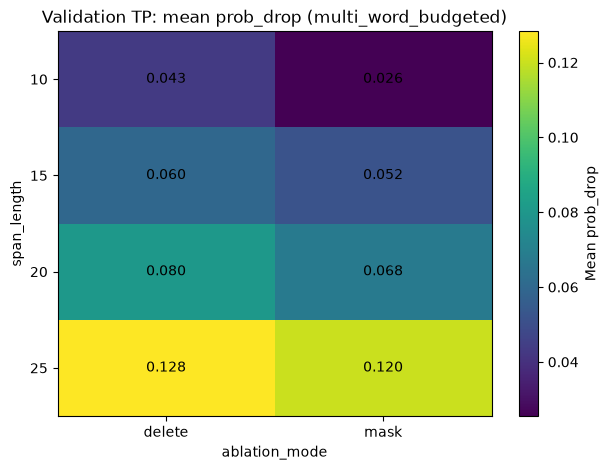

Saved plot: random_baseline_results/plots/random_val_tp_heatmap_multi_word_budgeted.png


ablation_mode,delete,mask
span_length,,
10,0.043026,0.025530
15,0.059997,0.051769
20,0.080427,0.067544
25,0.128407,0.120283


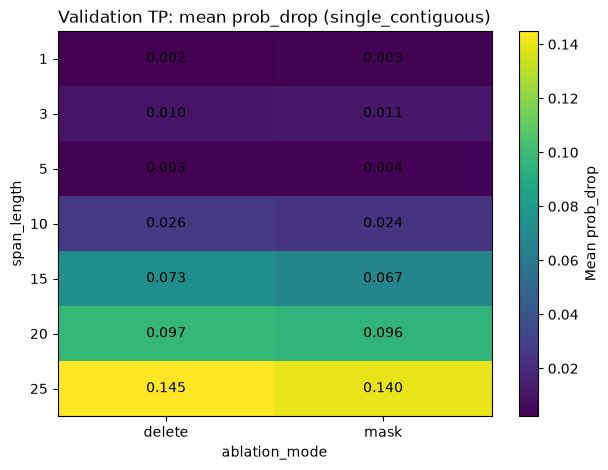

Saved plot: random_baseline_results/plots/random_val_tp_heatmap_single_contiguous.png


ablation_mode,delete,mask
span_length,,
1,0.002348,0.002923
3,0.010310,0.011398
5,0.003135,0.003900
10,0.026264,0.024424
15,0.073199,0.067402
20,0.097304,0.095714
25,0.144881,0.140079


In [25]:
for selection_mode in sorted(val_tp_config_summary["span_selection_mode"].unique()):
    subset = val_tp_config_summary[
        val_tp_config_summary["span_selection_mode"] == selection_mode
    ].copy()
    
    heatmap_data = subset.pivot(
        index="span_length",
        columns="ablation_mode",
        values="mean_prob_drop"
    )
    
    plt.figure(figsize=(7, 5))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label="Mean prob_drop")
    
    plt.xticks(
        ticks=np.arange(len(heatmap_data.columns)),
        labels=heatmap_data.columns
    )
    plt.yticks(
        ticks=np.arange(len(heatmap_data.index)),
        labels=heatmap_data.index
    )
    
    for y_idx, span_length in enumerate(heatmap_data.index):
        for x_idx, ablation_mode in enumerate(heatmap_data.columns):
            value = heatmap_data.loc[span_length, ablation_mode]
            plt.text(
                x_idx,
                y_idx,
                f"{value:.3f}",
                ha="center",
                va="center"
            )
    
    plt.xlabel("ablation_mode")
    plt.ylabel("span_length")
    plt.title(f"Validation TP: mean prob_drop ({selection_mode})")
    
    plot_path = PLOTS_DIR / f"random_val_tp_heatmap_{selection_mode}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)
    display(heatmap_data)

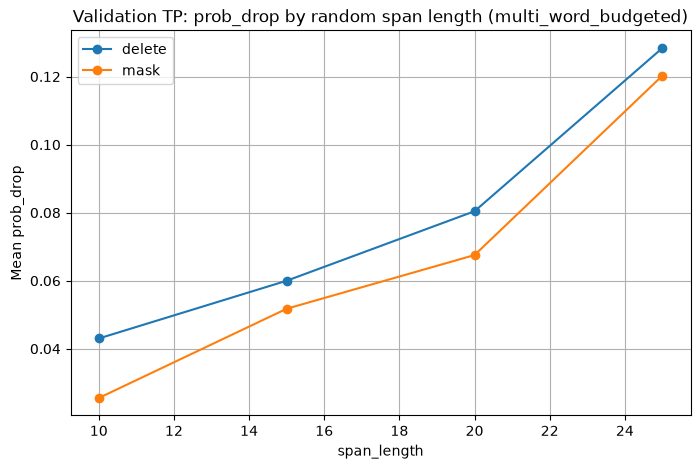

Saved plot: random_baseline_results/plots/random_val_tp_prob_drop_by_span_length_multi_word_budgeted.png


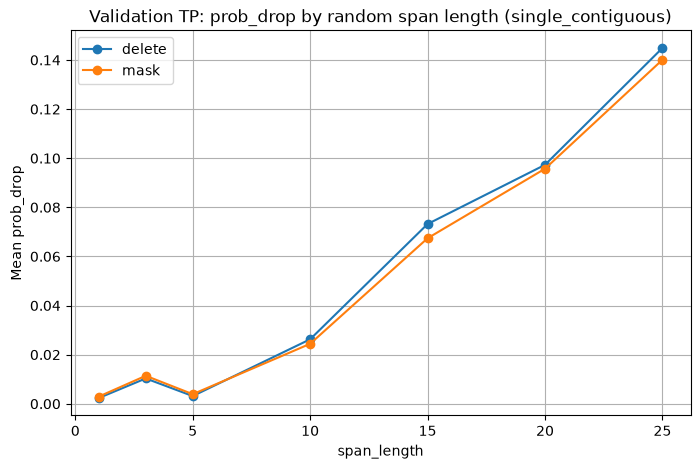

Saved plot: random_baseline_results/plots/random_val_tp_prob_drop_by_span_length_single_contiguous.png


In [26]:
for selection_mode in sorted(val_tp_config_summary["span_selection_mode"].unique()):
    subset_mode = val_tp_config_summary[
        val_tp_config_summary["span_selection_mode"] == selection_mode
    ].copy()
    
    plt.figure(figsize=(8, 5))
    
    for ablation_mode in sorted(subset_mode["ablation_mode"].unique()):
        subset = subset_mode[
            subset_mode["ablation_mode"] == ablation_mode
        ].sort_values("span_length")
        
        plt.plot(
            subset["span_length"],
            subset["mean_prob_drop"],
            marker="o",
            label=ablation_mode
        )
    
    plt.xlabel("span_length")
    plt.ylabel("Mean prob_drop")
    plt.title(f"Validation TP: prob_drop by random span length ({selection_mode})")
    plt.grid(True)
    plt.legend()
    
    plot_path = PLOTS_DIR / f"random_val_tp_prob_drop_by_span_length_{selection_mode}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

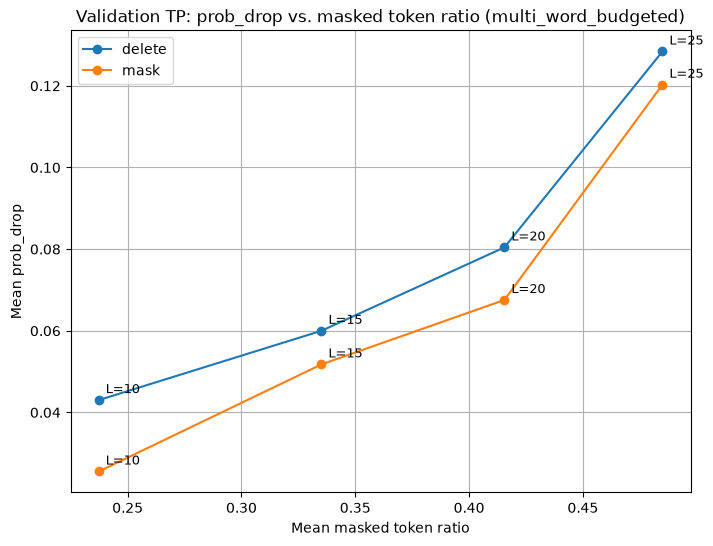

Saved plot: random_baseline_results/plots/random_val_tp_prob_drop_vs_masked_token_ratio_multi_word_budgeted.png


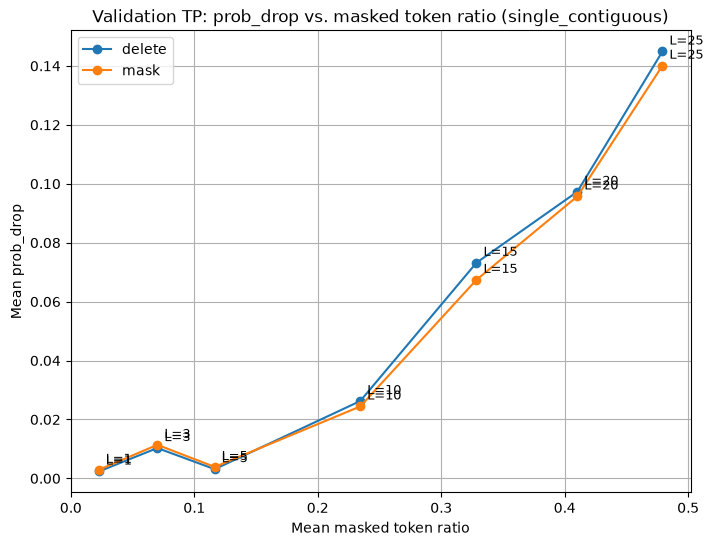

Saved plot: random_baseline_results/plots/random_val_tp_prob_drop_vs_masked_token_ratio_single_contiguous.png


In [27]:
for selection_mode in sorted(val_tp_config_summary["span_selection_mode"].unique()):
    subset_mode = val_tp_config_summary[
        val_tp_config_summary["span_selection_mode"] == selection_mode
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for ablation_mode in sorted(subset_mode["ablation_mode"].unique()):
        subset = subset_mode[
            subset_mode["ablation_mode"] == ablation_mode
        ].sort_values("mean_masked_token_ratio")
        
        plt.plot(
            subset["mean_masked_token_ratio"],
            subset["mean_prob_drop"],
            marker="o",
            label=ablation_mode
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"L={int(row['span_length'])}",
                (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Mean prob_drop")
    plt.title(f"Validation TP: prob_drop vs. masked token ratio ({selection_mode})")
    plt.grid(True)
    plt.legend()
    
    plot_path = PLOTS_DIR / f"random_val_tp_prob_drop_vs_masked_token_ratio_{selection_mode}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

In [28]:
ranked_val_configs = (
    val_tp_config_summary
    .sort_values(
        [
            "mean_prob_drop",
            "positive_drop_rate",
            "strong_drop_rate_001"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    ranked_val_configs[
        [
            "span_selection_mode",
            "span_length",
            "ablation_mode",
            "n_arguments",
            "mean_prob_drop",
            "median_prob_drop",
            "positive_drop_rate",
            "strong_drop_rate_001",
            "mean_masked_token_ratio",
            "mean_n_merged_spans"
        ]
    ]
)

ranked_val_configs.to_csv(
    OUTPUT_DIR / "random_validation_tp_ranked_configs.csv",
    index=False,
    encoding="utf-8"
)

,span_selection_mode,span_length,ablation_mode,n_arguments,mean_prob_drop,median_prob_drop,positive_drop_rate,strong_drop_rate_001,mean_masked_token_ratio,mean_n_merged_spans
0,single_contiguous,25,delete,88,0.144881,0.000198,0.493182,0.281818,0.479156,1.000000
1,single_contiguous,25,mask,88,0.140079,0.000275,0.495455,0.297727,0.479156,1.000000
2,multi_word_budgeted,25,delete,88,0.128407,0.000336,0.611364,0.259091,0.484950,13.445455
3,multi_word_budgeted,25,mask,88,0.120283,0.000578,0.722727,0.279545,0.484950,13.445455
4,single_contiguous,20,delete,88,0.097304,0.000331,0.495455,0.231818,0.410217,1.000000
5,single_contiguous,20,mask,88,0.095714,0.000409,0.504545,0.227273,0.410217,1.000000
6,multi_word_budgeted,20,delete,88,0.080427,0.000368,0.577273,0.204545,0.415512,12.095455
7,single_contiguous,15,delete,88,0.073199,0.000103,0.470455,0.168182,0.328559,1.000000
8,multi_word_budgeted,20,mask,88,0.067544,0.000500,0.704545,0.197727,0.415512,12.095455
9,single_contiguous,15,mask,88,0.067402,0.000071,0.463636,0.179545,0.328559,1.000000


In [29]:
test_per_argument_config_df = per_argument_config_df[
    per_argument_config_df["split"] == "test"
].copy()

test_config_summary = (
    test_per_argument_config_df
    .groupby(
        [
            "span_selection_mode",
            "span_length",
            "ablation_mode"
        ],
        as_index=False
    )
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("mean_prob_drop", "mean"),
        median_prob_drop=("mean_prob_drop", "median"),
        std_prob_drop=("mean_prob_drop", "std"),
        mean_max_prob_drop=("max_prob_drop", "mean"),
        positive_drop_rate=("positive_drop_rate", "mean"),
        strong_drop_rate_001=("strong_drop_rate_001", "mean"),
        strong_drop_rate_005=("strong_drop_rate_005", "mean"),
        mean_p_original=("mean_p_original", "mean"),
        mean_p_perturbed=("mean_p_perturbed", "mean"),
        mean_n_merged_spans=("mean_n_merged_spans", "mean"),
        mean_total_masked_tokens=("mean_total_masked_tokens", "mean"),
        mean_masked_token_ratio=("mean_masked_token_ratio", "mean"),
        truncation_rate=("truncation_rate", "mean")
    )
    .sort_values(
        [
            "span_selection_mode",
            "ablation_mode",
            "span_length"
        ]
    )
)

test_confusion_summary = (
    test_per_argument_config_df
    .groupby(
        [
            "confusion_type",
            "span_selection_mode",
            "span_length",
            "ablation_mode"
        ],
        as_index=False
    )
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("mean_prob_drop", "mean"),
        median_prob_drop=("mean_prob_drop", "median"),
        positive_drop_rate=("positive_drop_rate", "mean"),
        mean_masked_token_ratio=("mean_masked_token_ratio", "mean"),
        mean_n_merged_spans=("mean_n_merged_spans", "mean")
    )
    .sort_values(
        [
            "confusion_type",
            "span_selection_mode",
            "ablation_mode",
            "span_length"
        ]
    )
)

display(test_config_summary)
display(test_confusion_summary)

test_config_summary.to_csv(
    OUTPUT_DIR / "random_test_config_summary.csv",
    index=False,
    encoding="utf-8"
)

test_confusion_summary.to_csv(
    OUTPUT_DIR / "random_test_confusion_summary.csv",
    index=False,
    encoding="utf-8"
)

,span_selection_mode,span_length,ablation_mode,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_max_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_perturbed,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,truncation_rate
0,multi_word_budgeted,10,delete,438,-0.089353,-0.000185,0.236434,0.018152,0.408219,0.089041,0.051142,0.590804,0.680157,8.205479,12.037443,0.198473,0.0
2,multi_word_budgeted,15,delete,438,-0.104960,-0.000325,0.324740,0.019651,0.395434,0.122374,0.097717,0.590804,0.695764,10.942922,17.920091,0.290103,0.0
4,multi_word_budgeted,20,delete,438,-0.134548,-0.000341,0.385612,-0.001706,0.404566,0.150685,0.124658,0.590804,0.725352,13.085388,23.659361,0.365818,0.0
6,multi_word_budgeted,25,delete,438,-0.152807,-0.000522,0.437529,-0.025563,0.413242,0.176256,0.159361,0.590804,0.743611,14.636073,29.067580,0.431235,0.0
1,multi_word_budgeted,10,mask,438,-0.100077,-0.000189,0.244404,-0.013104,0.460731,0.071233,0.036073,0.590804,0.690881,8.205479,12.037443,0.198473,0.0
3,multi_word_budgeted,15,mask,438,-0.106250,-0.000076,0.316275,-0.008059,0.466667,0.117808,0.092237,0.590804,0.697054,10.942922,17.920091,0.290103,0.0
5,multi_word_budgeted,20,mask,438,-0.118633,0.000011,0.361236,-0.018153,0.483105,0.154795,0.120548,0.590804,0.709437,13.085388,23.659361,0.365818,0.0
7,multi_word_budgeted,25,mask,438,-0.129013,-0.000046,0.412095,-0.015518,0.485388,0.181279,0.155251,0.590804,0.719818,14.636073,29.067580,0.431235,0.0
8,single_contiguous,1,delete,438,-0.009726,-0.000012,0.058841,0.024832,0.442466,0.048858,0.022831,0.590804,0.600530,1.000000,1.198174,0.019977,0.0
10,single_contiguous,3,delete,438,-0.019385,-0.000037,0.096871,0.038027,0.415982,0.062557,0.031963,0.590804,0.610189,1.000000,3.542466,0.058111,0.0


,confusion_type,span_selection_mode,span_length,ablation_mode,n_arguments,mean_prob_drop,median_prob_drop,positive_drop_rate,mean_masked_token_ratio,mean_n_merged_spans
0,FN,multi_word_budgeted,10,delete,39,-0.358433,-0.403101,0.266667,0.164272,8.517949
2,FN,multi_word_budgeted,15,delete,39,-0.438644,-0.409928,0.153846,0.239801,11.682051
4,FN,multi_word_budgeted,20,delete,39,-0.544095,-0.617291,0.138462,0.305256,14.394872
6,FN,multi_word_budgeted,25,delete,39,-0.586064,-0.747742,0.097436,0.365580,16.251282
1,FN,multi_word_budgeted,10,mask,39,-0.360039,-0.123872,0.189744,0.164272,8.517949
...,...,...,...,...,...,...,...,...,...,...
79,TP,single_contiguous,5,mask,186,0.005131,0.000007,0.456989,0.117459,1.000000
81,TP,single_contiguous,10,mask,186,0.010551,0.000013,0.476344,0.236343,1.000000
83,TP,single_contiguous,15,mask,186,0.051713,0.000030,0.477419,0.347918,1.000000
85,TP,single_contiguous,20,mask,186,0.090911,0.000095,0.534409,0.426770,1.000000


In [30]:
def highlight_spans(text, spans):
    """Highlight multiple character spans in one text."""
    text = str(text)
    
    if not spans:
        return html.escape(text)
    
    spans = sorted(spans, key=lambda x: x["char_start"])
    
    parts = []
    last_end = 0
    
    for span in spans:
        start = int(span["char_start"])
        end = int(span["char_end"])
        
        if start < last_end:
            continue
        
        parts.append(html.escape(text[last_end:start]))
        parts.append(
            "<mark style='background-color:#ffe58a; padding:2px 4px; border-radius:4px;'>"
            + html.escape(text[start:end])
            + "</mark>"
        )
        last_end = end
    
    parts.append(html.escape(text[last_end:]))
    
    return "".join(parts)


def show_random_example(result_df, index=0):
    """Display one random baseline result with highlighted perturbed spans."""
    row = result_df.iloc[index]
    
    spans = json.loads(row["merged_spans_json"])
    marked = highlight_spans(row["text"], spans)
    
    display(HTML(f"""
    <div style="
        border:1px solid #ccc;
        border-radius:8px;
        padding:14px;
        margin:12px 0;
        font-family:Arial, sans-serif;
        line-height:1.45;
    ">
        <b>global_row_id:</b> {html.escape(str(row["global_row_id"]))}<br>
        <b>post_id:</b> {html.escape(str(row["post_id"]))}<br>
        <b>split:</b> {html.escape(str(row["split"]))}<br>
        <b>confusion_type:</b> {html.escape(str(row["confusion_type"]))}<br>
        <b>issue:</b> {html.escape(str(row["issue"]))}<br>
        <b>method:</b> {html.escape(str(row["attribution_method"]))}<br>
        <b>selection_mode:</b> {html.escape(str(row["span_selection_mode"]))} |
        <b>span_length:</b> {html.escape(str(row["span_length"]))} |
        <b>sample_id:</b> {html.escape(str(row["sample_id"]))} |
        <b>ablation_mode:</b> {html.escape(str(row["ablation_mode"]))}<br>
        <b>merged_spans:</b> {html.escape(str(row["merged_span_texts"]))}<br>
        <b>p_original:</b> {float(row["p_inappropriate_original"]):.4f}<br>
        <b>p_perturbed:</b> {float(row["p_inappropriate_perturbed"]):.4f}<br>
        <b>prob_drop:</b> {float(row["prob_drop"]):.4f}<br>
        <b>masked_token_ratio:</b> {float(row["masked_token_ratio"]):.4f}<br>
        <hr>
        <b>Original with highlighted random span(s):</b><br>
        <div style="margin-top:6px;">{marked}</div>
        <hr>
        <b>Perturbed text:</b><br>
        <div style="margin-top:6px; color:#555;">
            {html.escape(str(row["perturbed_text"]))}
        </div>
    </div>
    """))

In [31]:
test_argument_df_valid = test_argument_df[
    test_argument_df["error"].isna()
].copy()

tmp_top = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

print("Best random examples by probability drop:")

for i in range(min(5, len(tmp_top))):
    show_random_example(tmp_top, index=i)

Best random examples by probability drop:


In [32]:
tmp_low = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=True)
    .reset_index(drop=True)
)

print("Random examples with the smallest or negative probability drops:")

for i in range(min(5, len(tmp_low))):
    show_random_example(tmp_low, index=i)

Random examples with the smallest or negative probability drops:


## Random baseline evaluation summary

The random baseline was applied to all train, validation, and test instances without training or hyperparameter tuning. It samples spans independently of the classifier and of any attribution scores.

The main quantity is:

```text
prob_drop = p_inappropriate_original - p_inappropriate_perturbed